In [1]:
%pip install matplotlib seaborn scikit-learn pandas numpy
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import Libraries

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries Imported Successfully ✅")


Libraries Imported Successfully ✅


In [3]:
# Load Dataset

df = pd.read_csv("heart_disease_data.csv")

# First 5 rows
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
# Dataset Information

print("Shape of Dataset :", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())


Shape of Dataset : (303, 14)

Columns:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
# Statistical Summary

df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


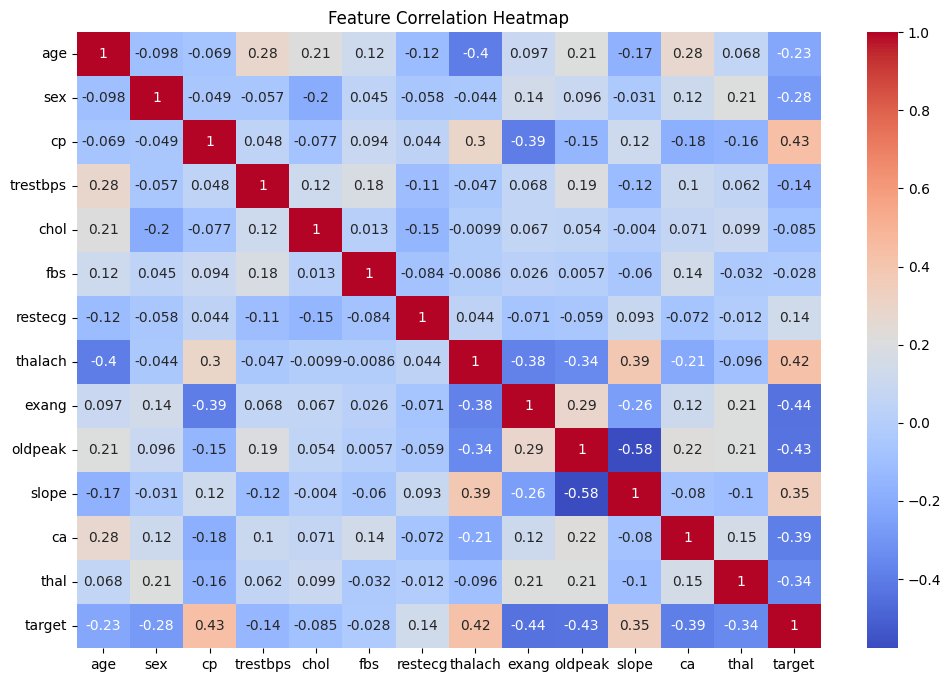

In [6]:
# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()


In [7]:
# Split Features and Target

X = df.drop('target', axis=1)
Y = df['target']

print(X.shape)
print(Y.shape)


(303, 13)
(303,)


In [8]:
# Train Test Split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=2
)

print("Training Data Shape :", X_train.shape)
print("Testing Data Shape :", X_test.shape)


Training Data Shape : (242, 13)
Testing Data Shape : (61, 13)


In [9]:
# Models Dictionary

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier()
}


In [10]:
# Train and Evaluate Models

results = []

for name, model in models.items():

    # Train
    model.fit(X_train, Y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(Y_train, train_pred)
    test_acc = accuracy_score(Y_test, test_pred)

    # Precision, Recall, F1
    precision = precision_score(Y_test, test_pred)
    recall = recall_score(Y_test, test_pred)
    f1 = f1_score(Y_test, test_pred)

    # Save results
    results.append([name, train_acc, test_acc, precision, recall, f1])

    print(f"\n{name}")
    print("-" * 40)

    print("Training Accuracy :", round(train_acc * 100, 2), "%")
    print("Testing Accuracy  :", round(test_acc * 100, 2), "%")
    print("Precision         :", round(precision, 2))
    print("Recall            :", round(recall, 2))
    print("F1 Score          :", round(f1, 2))

    print("\nConfusion Matrix:")
    print(confusion_matrix(Y_test, test_pred))

    print("\nClassification Report:")
    print(classification_report(Y_test, test_pred))



Logistic Regression
----------------------------------------
Training Accuracy : 83.06 %
Testing Accuracy  : 88.52 %
Precision         : 0.82
Recall            : 0.97
F1 Score          : 0.89

Confusion Matrix:
[[26  6]
 [ 1 28]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.81      0.88        32
           1       0.82      0.97      0.89        29

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.88        61


Random Forest
----------------------------------------
Training Accuracy : 100.0 %
Testing Accuracy  : 88.52 %
Precision         : 0.81
Recall            : 1.0
F1 Score          : 0.89

Confusion Matrix:
[[25  7]
 [ 0 29]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.78      0.88        32
           1       0.81      1.00      0.89        29

    ac

In [11]:
# Create Results DataFrame

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Training Accuracy',
        'Testing Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

results_df


,Model,Training Accuracy,Testing Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.830579,0.885246,0.823529,0.965517,0.888889
1,Random Forest,1.000000,0.885246,0.805556,1.000000,0.892308
2,Gradient Boosting,0.995868,0.885246,0.805556,1.000000,0.892308
3,AdaBoost,0.867769,0.885246,0.823529,0.965517,0.888889


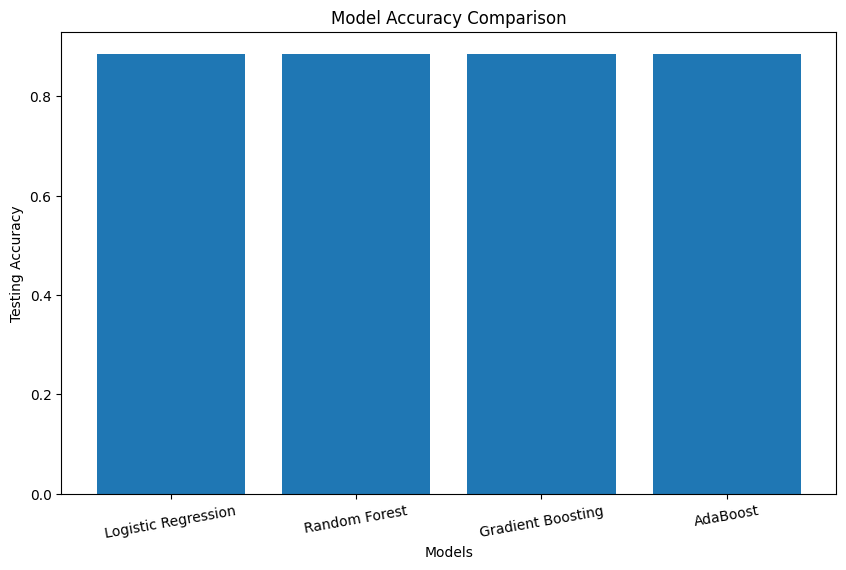

In [12]:
# Accuracy Comparison Graph

plt.figure(figsize=(10,6))

plt.bar(results_df['Model'], results_df['Testing Accuracy'])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Testing Accuracy")

plt.xticks(rotation=10)

plt.show()


In [13]:
# Save Best Model (Example: Random Forest)

import pickle

best_model = RandomForestClassifier()

best_model.fit(X_train, Y_train)

pickle.dump(best_model, open('heart_disease_model.pkl', 'wb'))

print("Model Saved Successfully ✅")


Model Saved Successfully ✅


# 🚀 Next Steps

You can now:

- Build a Streamlit App
- Deploy on Streamlit Cloud
- Improve UI Design
- Use XGBoost for better accuracy
- Add prediction visualizations
